(25000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N_Days         25000 non-null  int64  
 1   Status         25000 non-null  object 
 2   Drug           25000 non-null  object 
 3   Age            25000 non-null  int64  
 4   Sex            25000 non-null  object 
 5   Ascites        25000 non-null  object 
 6   Hepatomegaly   25000 non-null  object 
 7   Spiders        25000 non-null  object 
 8   Edema          25000 non-null  object 
 9   Bilirubin      25000 non-null  float64
 10  Cholesterol    25000 non-null  float64
 11  Albumin        25000 non-null  float64
 12  Copper         25000 non-null  float64
 13  Alk_Phos       25000 non-null  float64
 14  SGOT           25000 non-null  float64
 15  Tryglicerides  25000 non-null  float64
 16  Platelets      25000 non-null  float64
 17  Prothrombin    25000 non-null  float64

C:\Users\jaint\AppData\Local\Temp\ipykernel_192\4145719135.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\jaint\AppData\Local\Temp\ipykernel_192\4145719135.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

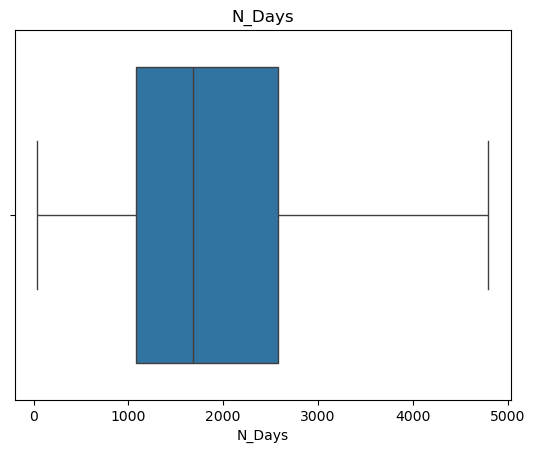

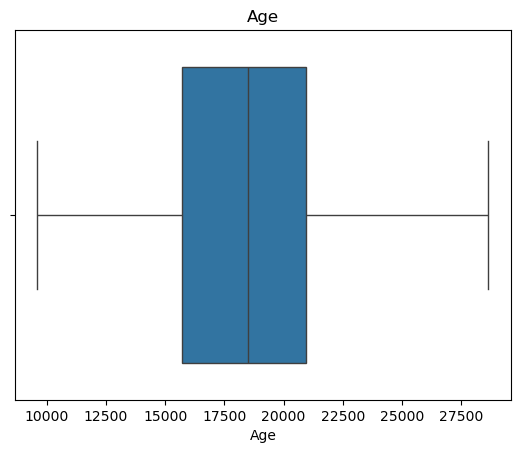

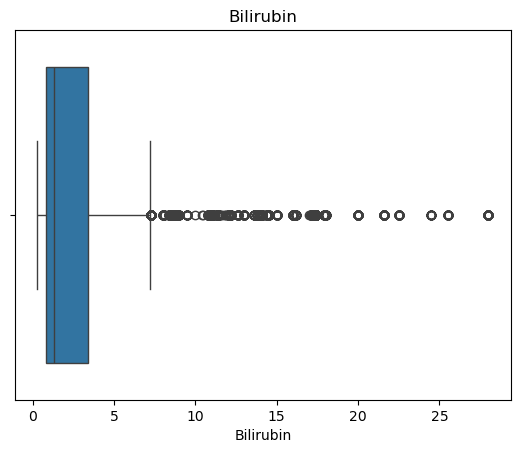

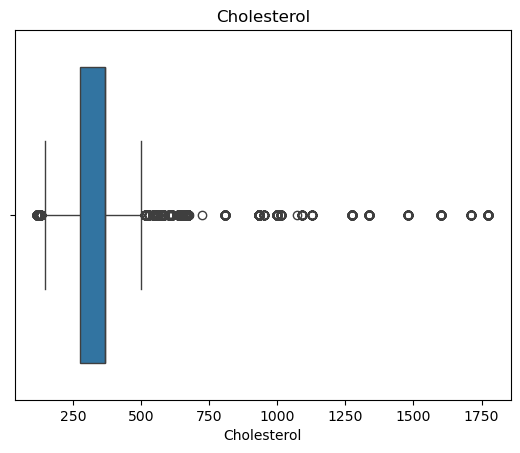

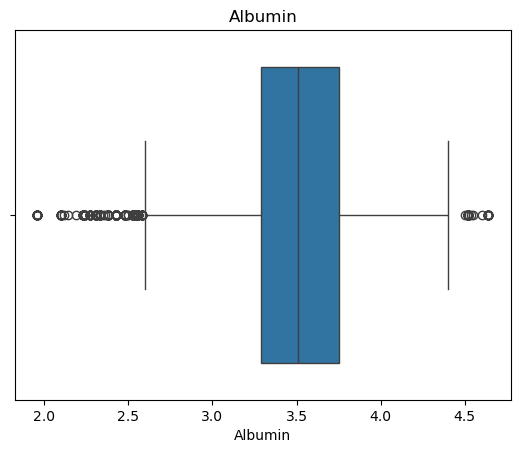

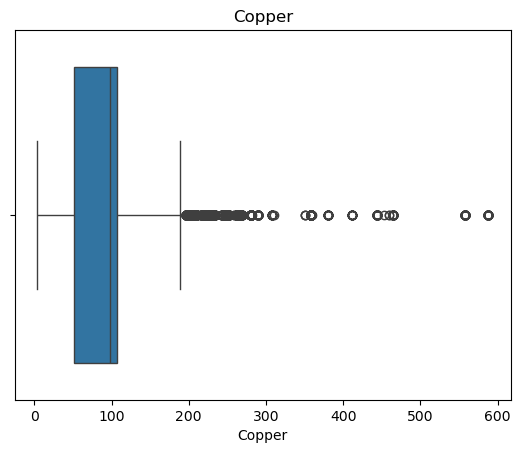

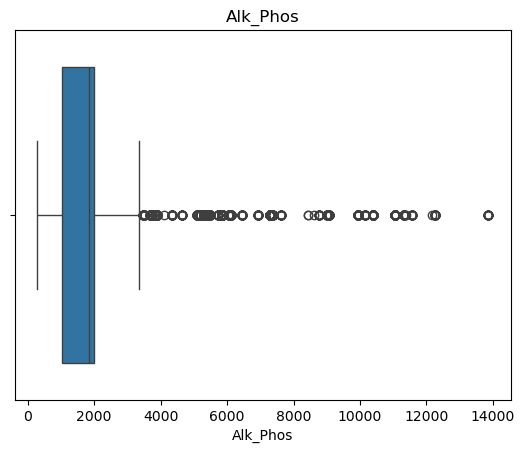

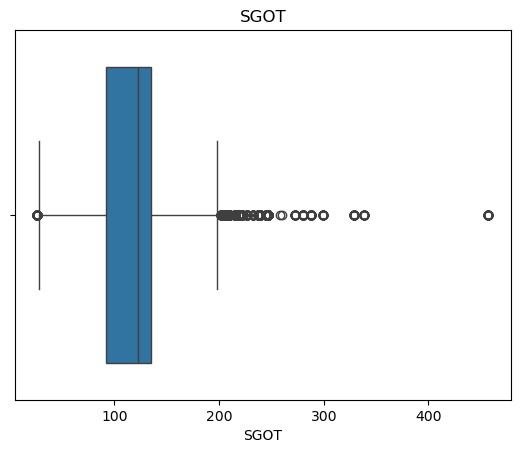

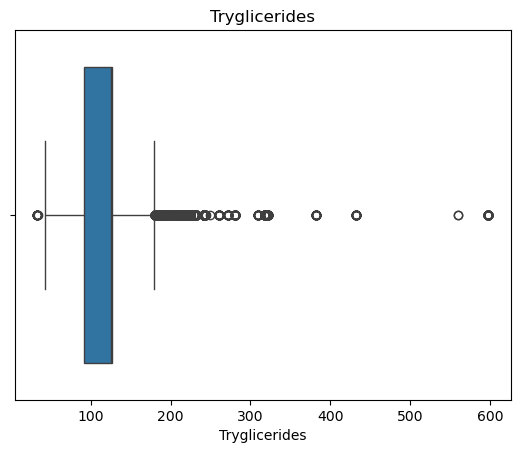

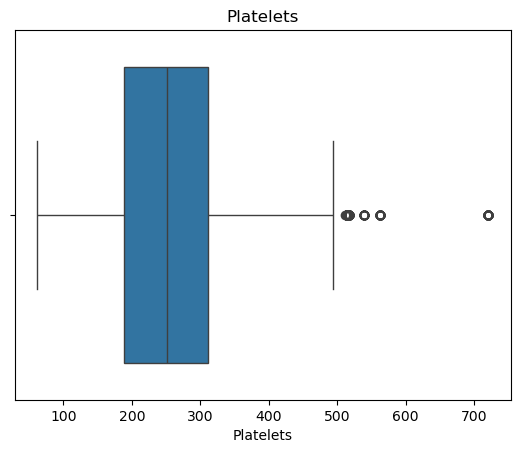

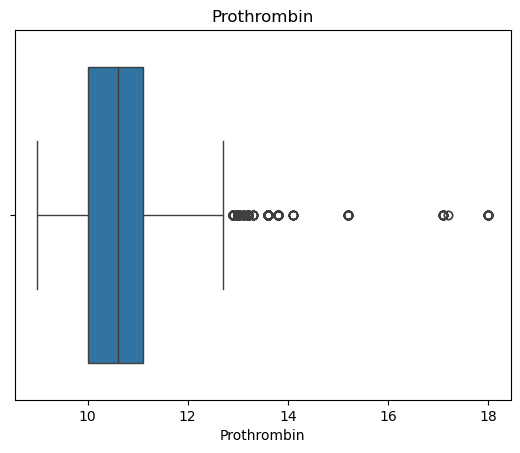

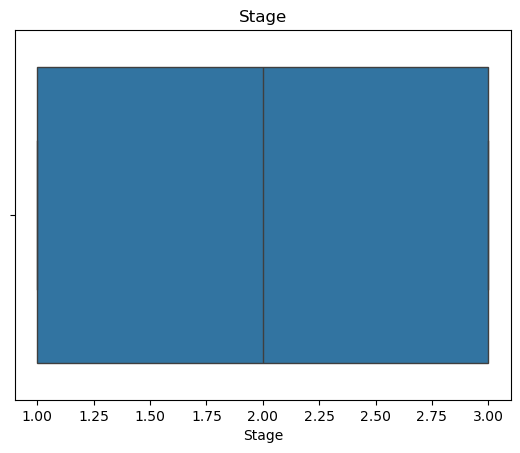

N_Days           0
Status           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64
             N_Days           Age     Bilirubin   Cholesterol       Albumin  \
count  25000.000000  25000.000000  25000.000000  25000.000000  25000.000000   
mean    1887.117040  18495.877080      2.546344    343.254203      3.490954   
std     1091.690918   3737.596616      2.359092     85.700147      0.365945   
min       41.000000   9598.000000      0.300000    133.234155      2.600000   
25%     1080.000000  15694.000000      0.800000    275.000000      3.290000   
50%     1680.000000  18499.000000      1.300000    369.510563      3.510000   
75%     2576.000000  20955.000000      3.400000    369.510563      3.7500

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Step 1: Load & Inspect ----
# Replace with your actual file path, e.g. 'pbc_data.csv'
df = pd.read_csv("../data/liver_cirrhosis.csv")

# Basic info
print(df.shape)        # rows, columns
print(df.info())       # dtypes & non-null counts
print(df.describe())   # summary stats for numeric cols
print(df.head())       # quick look at first rows

# Check unique values for categorical columns
cat_cols = ['Status','Drug','Sex','Ascites','Hepatomegaly','Spiders','Edema','Stage']
for c in cat_cols:
    print(f"{c}: {df[c].unique()}")

# ---- Step 2: Handle Missing Values ----
print("Missing values:\n", df.isna().sum())

# Example: fill numeric with median, categorical with mode
num_cols = df.select_dtypes(include=['float64','int64']).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# ---- Outlier Detection & Optional Treatment ----
# Visualize boxplots for numeric columns
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Simple IQR-based capping (example)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

# Verify changes
print(df.isna().sum())
print(df.describe())


In [10]:
# ---- Step 3: Target variable ----
# Stage distribution
print("Stage distribution:\n", df['Stage'].value_counts())

# If you want to separate features & target for modeling
X = df.drop(columns=['Stage'])
y = df['Stage']

# ---- Step 4: Encode categorical columns ----
# Map/encode each categorical feature
df_encoded = df.copy()

# Simple mappings
df_encoded['Status']  = df_encoded['Status'].map({'C':0, 'CL':1, 'D':2})
df_encoded['Drug']    = df_encoded['Drug'].map({'Placebo':0, 'D-penicillamine':1})
df_encoded['Sex']     = df_encoded['Sex'].map({'F':0, 'M':1})
df_encoded['Ascites'] = df_encoded['Ascites'].map({'N':0, 'Y':1})
df_encoded['Hepatomegaly'] = df_encoded['Hepatomegaly'].map({'N':0, 'Y':1})
df_encoded['Spiders'] = df_encoded['Spiders'].map({'N':0, 'Y':1})
# Edema has 3 levels: N=0, S=1, Y=2
df_encoded['Edema']   = df_encoded['Edema'].map({'N':0, 'S':1, 'Y':2})

print("\nPreview after encoding:")
print(df_encoded.head())

# Separate features & target if needed
X = df_encoded.drop(columns=['Stage'])
y = df_encoded['Stage']


Stage distribution:
 Stage
2    8441
3    8294
1    8265
Name: count, dtype: int64

Preview after encoding:
   N_Days  Status  Drug    Age  Sex  Ascites  Hepatomegaly  Spiders  Edema  \
0    2221       0     0  18499    0        0             1        0      0   
1    1230       0     0  19724    1        1             0        1      0   
2    4184       0     0  11839    0        0             0        0      0   
3    2090       2     0  16467    0        0             0        0      0   
4    2105       2     0  21699    0        0             1        0      0   

   Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  Tryglicerides  \
0        0.5        149.0     4.04   189.5     598.0   52.70           57.0   
1        0.5        219.0     3.93    22.0     663.0   45.00           75.0   
2        0.5        320.0     3.54    51.0    1243.0  122.45           80.0   
3        0.7        255.0     3.74    23.0    1024.0   77.50           58.0   
4        1.9        486.0   

In [11]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# ---- Step 5: Feature Transformation ----
df_transformed = df_encoded.copy()

# Age in years
df_transformed['Age_years'] = df_transformed['Age'] / 365.0

# Drop old Age if you prefer
df_transformed.drop(columns=['Age'], inplace=True)

# Log transform skewed columns (add 1 to avoid log(0))
skew_cols = ['Bilirubin', 'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides']
for col in skew_cols:
    df_transformed[col] = np.log1p(df_transformed[col])

print("\nPreview after transformations:")
print(df_transformed.head())

# ---- Step 6: Scaling ----
# Identify continuous numeric columns to scale
continuous_cols = [
    'N_Days','Age_years','Bilirubin','Cholesterol','Albumin','Copper',
    'Alk_Phos','SGOT','Tryglicerides','Platelets','Prothrombin'
]

scaler = StandardScaler()
df_transformed[continuous_cols] = scaler.fit_transform(df_transformed[continuous_cols])

print("\nScaled data sample:")
print(df_transformed.head())

# Final feature matrix and target
X = df_transformed.drop(columns=['Stage'])
y = df_transformed['Stage']



Preview after transformations:
   N_Days  Status  Drug  Sex  Ascites  Hepatomegaly  Spiders  Edema  \
0    2221       0     0    0        0             1        0      0   
1    1230       0     0    1        1             0        1      0   
2    4184       0     0    0        0             0        0      0   
3    2090       2     0    0        0             0        0      0   
4    2105       2     0    0        0             1        0      0   

   Bilirubin  Cholesterol  Albumin    Copper  Alk_Phos      SGOT  \
0   0.405465     5.010635     4.04  5.249652  6.395262  3.983413   
1   0.405465     5.393628     3.93  3.135494  6.498282  3.828641   
2   0.405465     5.771441     3.54  3.951244  7.126087  4.815836   
3   0.530628     5.545177     3.74  3.178054  6.932448  4.363099   
4   1.064711     6.188264     3.54  4.317488  6.959399  4.695925   

   Tryglicerides  Platelets  Prothrombin  Stage  Age_years  
0       4.060443      256.0          9.9      1  50.682192  
1       4.

In [13]:
# Combine features and target back together
final_df = pd.concat([X, y], axis=1)

# Save to CSV without the index
final_df.to_csv("../data/liver_cirrhosis_clean.csv", index=False)

print("Clean dataset saved as liver_cirrhosis_clean.csv")


Clean dataset saved as liver_cirrhosis_clean.csv
